In [1]:
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Normalization
from tensorflow.keras import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
random.seed(1234)
np.random.seed(1234)
tf.random.set_seed(1234)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
df = df.sample(frac=1, random_state=1234).reset_index(drop=True)

In [5]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [6]:
Y = Y.replace({'R':0, 'M':1})

In [7]:
X = X.values
Y = Y.values
X = X.astype('float32')
Y = Y.astype('float32')

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1234, shuffle=True, stratify=Y)

In [9]:
norm = Normalization(axis = -1)
norm.adapt(x_train)
x_train = norm(x_train)
x_test = norm(x_test)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8)

[]

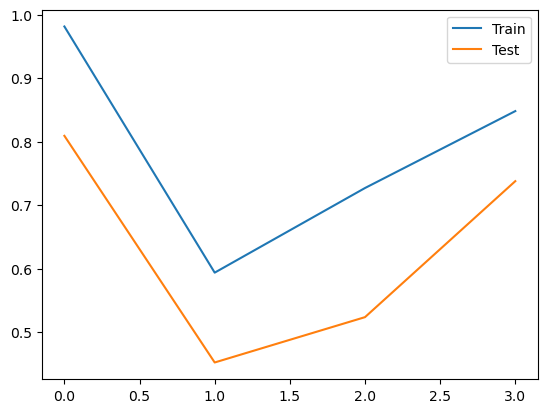

In [11]:
units_list = [(15, 8), (30, 15), (45, 22), (60, 30)]

acc_train = []
acc_test = []

for lay1, lay2 in units_list:
    tf.random.set_seed(1234)
    
    model = Sequential([
        tf.keras.Input(shape=(60,)),
        Dense(units=lay1, activation='relu'),
        Dense(units=lay2, activation='relu'),
        Dense(units=2, activation='linear')
    ])

    model.compile(
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005),
                loss=SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=100, callbacks=[early_stop], validation_data=(x_test, y_test), verbose=0)

    acc_train.append(model.evaluate(x_train, y_train, verbose=0)[1])
    acc_test.append(model.evaluate(x_test, y_test, verbose=0)[1]) 

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.plot()
    

In [13]:
print(f"Accuracy of test dataset is {acc_test[0]}\nAccuracy of train dataset is {acc_train[0]}")

Accuracy of test dataset is 0.8095238208770752
Accuracy of train dataset is 0.9818181991577148


[]

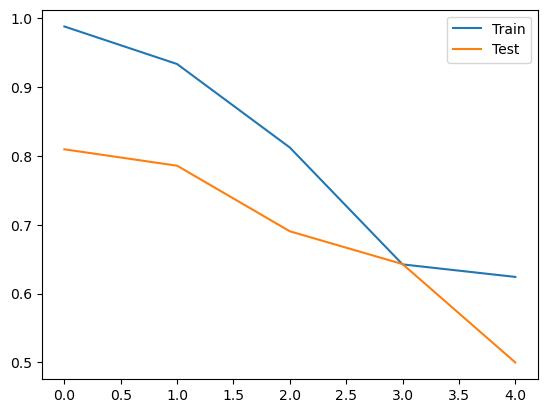

In [14]:
#so we now fix the units = (15, 8) for best test accuracy

learning_rates= [0.01, 0.005, 0.001, 0.0005, 0.0001]

acc_train = []
acc_test = []

for alpha in learning_rates:
    tf.random.set_seed(1234)

    model = Sequential([
        tf.keras.Input(shape=(60,)),
        Dense(units=15, activation='relu'),
        Dense(units=8, activation='relu'),
        Dense(units=2, activation='linear')
    ])

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=alpha),
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=100, callbacks=[early_stop], validation_data=(x_test, y_test), verbose=0)

    acc_train.append(model.evaluate(x_train, y_train, verbose=0)[1])
    acc_test.append(model.evaluate(x_test, y_test, verbose=0)[1]) 

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.plot()
            

In [19]:
print(f"Accuracy of test dataset is {acc_test[1]}\nAccuracy of train dataset is {acc_train[1]}")

Accuracy of test dataset is 0.7857142686843872
Accuracy of train dataset is 0.9212121367454529


[]

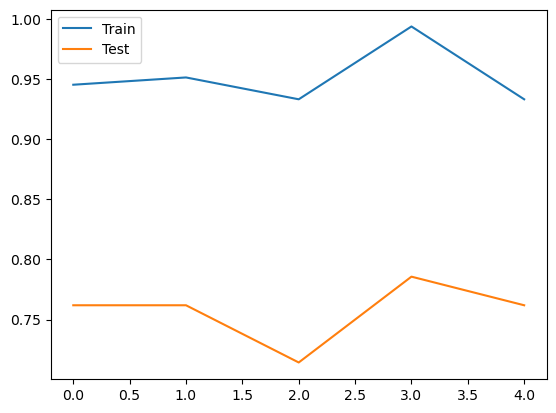

In [15]:
# 0.005 learning rate is fixed

lambdas = [0.001, 0.0001, 0.00005, 0.00001, 0.0]

acc_train = []
acc_test = []

for lam in lambdas:
    tf.random.set_seed(1234)

    model = Sequential([
        tf.keras.Input(shape=(60,)),
        Dense(units=15, activation='relu', kernel_regularizer=l2(lam)),
        Dense(units=8, activation='relu', kernel_regularizer=l2(lam)),
        Dense(units=2, activation='linear')
    ])

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.005),
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=100, callbacks=[early_stop], validation_data=(x_test, y_test), verbose=0)

    acc_train.append(model.evaluate(x_train, y_train, verbose=0)[1])
    acc_test.append(model.evaluate(x_test, y_test, verbose=0)[1]) 

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.plot()
            

In [16]:
print(f"Accuracy of test dataset is {acc_test[3]}\nAccuracy of train dataset is {acc_train[3]}")

Accuracy of test dataset is 0.7857142686843872
Accuracy of train dataset is 0.9939393997192383


In [19]:
#regularization = 0.00001 is best for the model so final

tf.random.set_seed(1234)

model = Sequential([
    tf.keras.Input(shape=(60,)),
    Dense(units=15, activation='relu', kernel_regularizer=l2(0.00001)),
    Dense(units=8, activation='relu', kernel_regularizer=l2(0.00001)),
    Dense(units=2, activation='linear')
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.005),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=100, callbacks=[early_stop], validation_data=(x_test, y_test), verbose=0)

In [20]:
training_accuracy = model.evaluate(x_train, y_train, verbose = 0)[1]
test_accuracy = model.evaluate(x_test, y_test, verbose=0)[1]

print(f"Accuracy of test dataset is {test_accuracy*100: .2f}\nAccuracy of train dataset is {training_accuracy*100: .2f}")

Accuracy of test dataset is  78.57
Accuracy of train dataset is  92.73


In [22]:
model.save('best_model.keras')